Trainable parameters: 7355
Epoch 01/20 | Loss: 0.266035
Epoch 02/20 | Loss: 0.230535
Epoch 03/20 | Loss: 0.223399
Epoch 04/20 | Loss: 0.219600
Epoch 05/20 | Loss: 0.217644
Epoch 06/20 | Loss: 0.216289
Epoch 07/20 | Loss: 0.215337
Epoch 08/20 | Loss: 0.214691
Epoch 09/20 | Loss: 0.214207
Epoch 10/20 | Loss: 0.213833
Epoch 11/20 | Loss: 0.213534
Epoch 12/20 | Loss: 0.213257
Epoch 13/20 | Loss: 0.213095
Epoch 14/20 | Loss: 0.212950
Epoch 15/20 | Loss: 0.212810
Epoch 16/20 | Loss: 0.212659
Epoch 17/20 | Loss: 0.212559
Epoch 18/20 | Loss: 0.212446
Epoch 19/20 | Loss: 0.212311
Epoch 20/20 | Loss: 0.212212


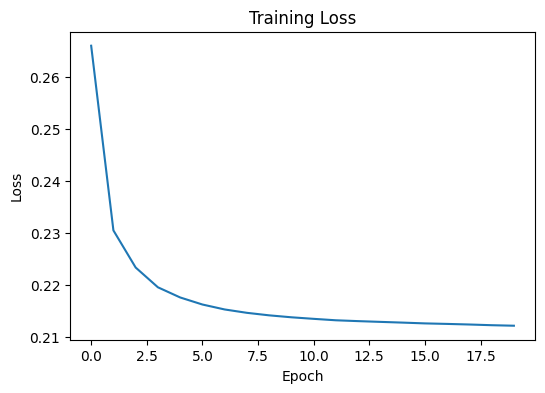

/var/folders/bb/8xmbn4cs4jzg1frdwwymlcz80000gn/T/ipykernel_88601/1504438976.py:217: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  all_y.append(np.array(ytrain))


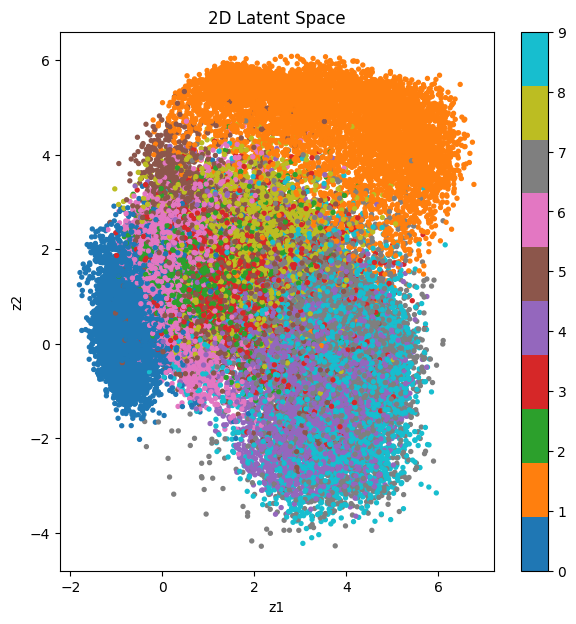

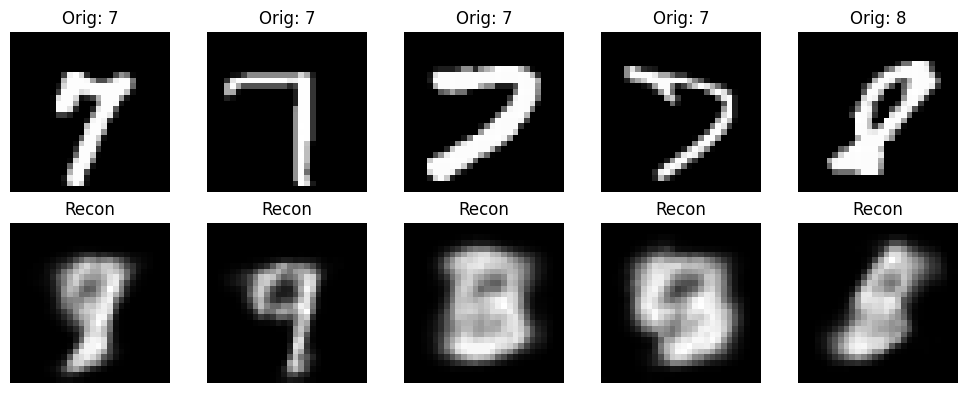

In [68]:
import math
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import jax
import jax.numpy as jnp
import equinox as eqx
import optax


# ============================================================
# 1) Data
# ============================================================
# Keep images in [0, 1] so sigmoid output + BCE loss make sense.
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(
    root="../data",
    train=True,
    download=True,
    transform=transform
)

trainloader = DataLoader(
    train_dataset,
    batch_size=64,   # 64 is a good lightweight default
    shuffle=True
)


# ============================================================
# 2) Model
# ============================================================

class Encoder(eqx.Module):
    l1: eqx.nn.Linear
    l2: eqx.nn.Linear
    l3: eqx.nn.Linear
    l4: eqx.nn.Linear

    def __init__(self, input_shape, latent_dim, key):
        in_features = math.prod(input_shape)
        k1, k2, k3, k4 = jax.random.split(key, 4)

        self.l1 = eqx.nn.Linear(in_features, 512, key=k1)
        self.l2 = eqx.nn.Linear(512, 256, key=k2)
        self.l3 = eqx.nn.Linear(256, 64, key=k3)
        self.l4 = eqx.nn.Linear(64, latent_dim, key=k4)

    def __call__(self, x):
        x = jnp.ravel(x)
        x = jax.nn.gelu(self.l1(x))
        x = jax.nn.gelu(self.l2(x))
        x = jax.nn.gelu(self.l3(x))
        z = self.l4(x)
        return z


class Decoder(eqx.Module):
    l1: eqx.nn.Linear
    l2: eqx.nn.Linear
    l3: eqx.nn.Linear
    l4: eqx.nn.Linear
    output_shape: tuple

    def __init__(self, input_shape, latent_dim, key):
        out_features = math.prod(input_shape)
        k1, k2, k3, k4 = jax.random.split(key, 4)

        self.l1 = eqx.nn.Linear(latent_dim, 64, key=k1)
        self.l2 = eqx.nn.Linear(64, 256, key=k2)
        self.l3 = eqx.nn.Linear(256, 512, key=k3)
        self.l4 = eqx.nn.Linear(512, out_features, key=k4)
        self.output_shape = input_shape

    def __call__(self, z):
        x = jax.nn.gelu(self.l1(z))
        x = jax.nn.gelu(self.l2(x))
        x = jax.nn.gelu(self.l3(x))
        x = self.l4(x)

        # use sigmoid if your images are in [0,1]
        x = jax.nn.sigmoid(x)

        # if your images are normalized to [-1, 1], use this instead:
        # x = jnp.tanh(x)

        x = jnp.reshape(x, self.output_shape)
        return x


class AutoEncoder(eqx.Module):
    encoder: Encoder
    decoder: Decoder

    def __init__(self, input_shape, latent_dim, key):
        k1, k2 = jax.random.split(key, 2)
        self.encoder = Encoder(input_shape, latent_dim, k1)
        self.decoder = Decoder(input_shape, latent_dim, k2)

    def __call__(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat


# ============================================================
# 3) Helpers
# ============================================================
def torch_batch_to_jax(x):
    return jnp.asarray(x.detach().cpu().numpy(), dtype=jnp.float32)


def reconstruction_bce(model, x_batch):
    x_hat_batch = jax.vmap(model)(x_batch)
    eps = 1e-7
    x_hat_batch = jnp.clip(x_hat_batch, eps, 1.0 - eps)
    loss = -(
        x_batch * jnp.log(x_hat_batch)
        + (1.0 - x_batch) * jnp.log(1.0 - x_hat_batch)
    )
    return jnp.mean(loss)


# Small regularization helps a bit without making the model complicated.
def loss_fn(model, x_batch, weight_decay=1e-5):
    recon_loss = reconstruction_bce(model, x_batch)

    params = eqx.filter(model, eqx.is_array)
    l2 = sum(jnp.sum(p ** 2) for p in jax.tree_util.tree_leaves(params))

    return recon_loss + weight_decay * l2


def count_parameters(model):
    leaves = jax.tree_util.tree_leaves(eqx.filter(model, eqx.is_array))
    return sum(x.size for x in leaves)


# ============================================================
# 4) Init
# ============================================================
key = jax.random.PRNGKey(0)
latent_dim = 2   # 2D latent space for plotting

model = SmallConvAE(latent_dim=latent_dim, key=key)
print("Trainable parameters:", count_parameters(model))

# Clip + Adam is a lightweight stable setup.
optimizer = optax.chain(
    optax.clip_by_global_norm(1.0),
    optax.adam(1e-3),
)
opt_state = optimizer.init(eqx.filter(model, eqx.is_array))


# ============================================================
# 5) Train step
# ============================================================
@eqx.filter_jit
def train_step(model, opt_state, x_batch):
    loss, grads = eqx.filter_value_and_grad(loss_fn)(model, x_batch)
    updates, opt_state = optimizer.update(
        grads, opt_state, eqx.filter(model, eqx.is_array)
    )
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss


# ============================================================
# 6) Training loop
# ============================================================
num_epochs = 20
loss_history = []

for epoch in range(num_epochs):
    epoch_losses = []

    for Xtrain, _ in trainloader:
        x_batch = torch_batch_to_jax(Xtrain)
        model, opt_state, loss = train_step(model, opt_state, x_batch)
        epoch_losses.append(float(loss))

    mean_epoch_loss = np.mean(epoch_losses)
    loss_history.append(mean_epoch_loss)
    print(f"Epoch {epoch+1:02d}/{num_epochs} | Loss: {mean_epoch_loss:.6f}")


# ============================================================
# 7) Plot training loss
# ============================================================
plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()


# ============================================================
# 8) Plot latent space
# ============================================================
all_z = []
all_y = []

for Xtrain, ytrain in trainloader:
    x_batch = torch_batch_to_jax(Xtrain)
    z_batch = jax.vmap(model.encode)(x_batch)

    all_z.append(np.array(z_batch))
    all_y.append(np.array(ytrain))

all_z = np.concatenate(all_z, axis=0)
all_y = np.concatenate(all_y, axis=0)

plt.figure(figsize=(7, 7))
plt.scatter(all_z[:, 0], all_z[:, 1], c=all_y, cmap="tab10", s=8)
plt.xlabel("z1")
plt.ylabel("z2")
plt.title("2D Latent Space")
plt.colorbar()
plt.show()


# ============================================================
# 9) Show original vs reconstruction
# ============================================================
Xtrain, ytrain = next(iter(trainloader))
x_batch = torch_batch_to_jax(Xtrain)
x_hat_batch = jax.vmap(model)(x_batch)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i in range(5):
    axes[0, i].imshow(np.array(x_batch[i].squeeze()), cmap="gray")
    axes[0, i].set_title(f"Orig: {int(ytrain[i])}")
    axes[0, i].axis("off")

    axes[1, i].imshow(np.array(x_hat_batch[i].squeeze()), cmap="gray")
    axes[1, i].set_title("Recon")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()